# Pha R (mo rong) — Buoc 2: Huan luyen T_phi tren du lieu periodic coupling

Dung DUNG kien truc/sieu tham so nhu Pha R goc (`configs/mine/amortized.yaml`) - vi ablation truoc da xac nhan dung luong mang khong phai van de, nen KHONG can thu lai voi mang nho o day. Bien duy nhat thay doi la **loai du lieu train** (periodic thay vi VAR tuyen tinh).

**Thoi gian:** corpus nho hon ban goc (~1/3 quy mo) nen ky vong nhanh hon dang ke - luon chay o uoc tinh thoi gian truoc.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import yaml, time, numpy as np, torch
from pathlib import Path

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.estimators.mine.amortized import train_amortized, AmortizedTrainConfig

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'mine'/'amortized.yaml', encoding='utf-8'))
corpus_dir = BASE / 'data' / 'interim' / 'synthetic_corpus_periodic'
train_windows = load_corpus(str(corpus_dir / 'train.npz'))
val_windows = load_corpus(str(corpus_dir / 'val.npz'))
print(f'train={len(train_windows)}, val={len(val_windows)}')

train=8160, val=1440


## 1. Uoc tinh thoi gian (LUON chay truoc)

In [2]:
probe_cfg = AmortizedTrainConfig(**cfg['train'])
probe_cfg.max_epochs = 2
t0 = time.time()
_, _ = train_amortized(train_windows, val_windows, probe_cfg)
t_epoch = (time.time()-t0)/2
full_epochs = cfg['train']['max_epochs']
print(f'Thoi gian/epoch: {t_epoch:.2f}s -> uoc tinh full {full_epochs} epoch: '
      f'{t_epoch*full_epochs/60:.1f} phut')

Thoi gian/epoch: 42.73s -> uoc tinh full 100 epoch: 71.2 phut


## 2. Huan luyen day du

In [3]:
train_cfg = AmortizedTrainConfig(**cfg['train'])
t0 = time.time()
est_periodic, hist_periodic = train_amortized(train_windows, val_windows, train_cfg)
print(f'Xong sau {(time.time()-t0)/60:.1f} phut, '
      f'{len(hist_periodic["val_loss_history"])} epoch, '
      f'trung binh {hist_periodic["n_epochs_averaged"]} epoch cuoi de deploy')

Xong sau 70.7 phut, 100 epoch, trung binh 10 epoch cuoi de deploy


## 3. Loss curve

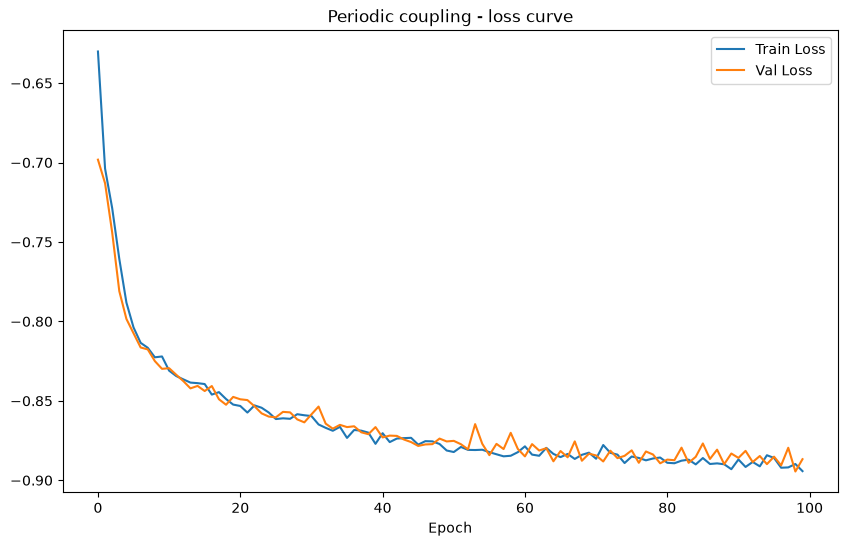

Val loss std (last 10): 0.004176760573054168


In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(hist_periodic['train_loss_history'], label='Train Loss')
plt.plot(hist_periodic['val_loss_history'], label='Val Loss')
plt.legend(); plt.xlabel('Epoch'); plt.title('Periodic coupling - loss curve')
out_dir = BASE / 'results' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'phase_r2_periodic_training_loss.png', dpi=100)
plt.show()
print('Val loss std (last 10):', np.std(hist_periodic['val_loss_history'][-10:]))

## 4. Luu checkpoint

In [5]:
ckpt_dir = BASE / 'results' / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)
est_periodic.save(str(ckpt_dir / 'phi_amortized_periodic.pt'))
print('Saved.')

Saved.
